# POOD Dataset Purification EBM vs DM-DDPM

In [4]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import json
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

dataset_dict = {
    'cifar10': 'CIFAR-10*',
    'cinic10_imagenet': 'CINIC-10_IN',
    'office_home': 'Office-Home',
    'textures': 'Dtd-Textures',
    'lfw_people': 'LFW People',
    'flowers102': 'Flowers-102',
    'food101': 'Food-101',
    'oxford_iiit_pet': 'Oxford-IIIT-Pet',
    'fgvc_aircraft': 'FGVC-Aircraft',
}

dataset_fids = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/dataset_FIDs.csv')
dataset_fids = dataset_fids.set_index('ood_dataset')['fid_score_mean'].to_dict()
# Convert values to ints
dataset_fids = {k: int(v) for k, v in dataset_fids.items()}

MODEL = 'ResNet18_HLB'

## Narcissus

/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_96682/56257437.py:59: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_96682/56257437.py:60: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(pivot_table.columns, rotation=35, ha='right',fontweight='bold',fontsize=14)
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_96682/56257437.py:74: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_96682/56257437.py:75: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_xticklabels(pivot_table.columns, rotation=35, ha='right',fontweight='bold',fontsize=14)


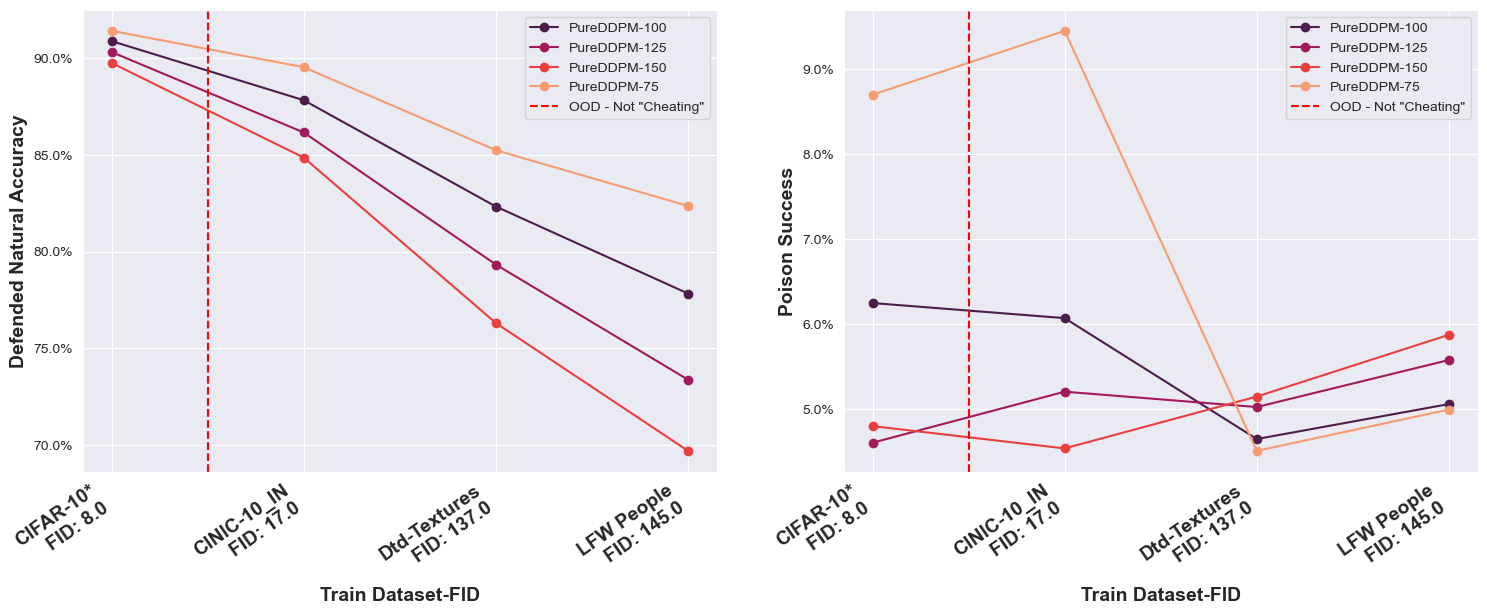

In [5]:
### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/Narcissus/POOD.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

EPS = 16

### Filter Data
df = df[df['noise_eps_narcissus'] == EPS]
df = df[df['Model'] == MODEL]

### Compile Results
df_results = []
for data_key in df['Data Key'].unique():
    df_filt = df[df['Data Key'] == data_key]

    # Extract the defense name
    label = data_key.split('[')[0]

    if label == 'EBM': continue

    # Get Steps
    if label in ['DM_UNET']:
        train_dataset = data_key.split('[')[1].split('_DDPM')[0]
        steps = int(data_key.split('_T[')[1].split(']')[0])
    else:
        steps = int(data_key.split('Steps[')[1].split(']')[0])
        train_dataset = data_key.split('[')[1].split('_nf')[0]
        

    df_results.append({'Defense': 'PureEBM' if label == 'EBMSNGAN32' else 'PureDDPM',
                        'Steps': steps,
                        'Defense Str': f"PureEBM-{steps}" if label == 'EBMSNGAN32' else f"PureDDPM-{steps}",
                        'Train Dataset': dataset_dict[train_dataset],
                        'FIDs': dataset_fids[train_dataset],
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                        'Poison Success': df_filt['P1 Acc'].mean(),
                        'Poison Success Str': f"{df_filt['P1 Acc'].mean()*100:.2f}\u00B1{df_filt['P1 Acc'].std()*100:.2f}",
                        'Max Poison Success': df_filt['P1 Acc'].max(),
                        'Max Poison Success Str': f"{df_filt['P1 Acc'].max()*100:.2f}",
                        'Num Results': len(df_filt),
                    })

df_results = pd.DataFrame(df_results)
# df_results

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Plot Natural Accuracy
pivot_table = df_results.pivot_table(index='Defense Str', columns=['FIDs','Train Dataset'], values='Nat Acc')
pivot_table.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in pivot_table.columns]
cmap = sns.color_palette('rocket', 4) + sns.color_palette('viridis', 4)

for i, row in enumerate(pivot_table.iterrows()):
    index, values = row
    axs[0].plot(pivot_table.columns, values, marker='o', color=cmap[i], label=index)

axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])
axs[0].set_xticklabels(pivot_table.columns, rotation=35, ha='right',fontweight='bold',fontsize=14)
axs[0].set_xlabel('Train Dataset-FID', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Defended Natural Accuracy', fontsize=14, fontweight='bold')
axs[0].axvline(x=0.5, color='r', linestyle='--',label='OOD - Not "Cheating"')
axs[0].legend()

# Plot Poison Defense
pivot_table = df_results.pivot_table(index='Defense Str', columns=['FIDs','Train Dataset'], values='Poison Success')
pivot_table.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in pivot_table.columns]

for i, row in enumerate(pivot_table.iterrows()):
    index, values = row
    axs[1].plot(pivot_table.columns, values, marker='o', color=cmap[i], label=index)

axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])
axs[1].set_xticklabels(pivot_table.columns, rotation=35, ha='right',fontweight='bold',fontsize=14)
axs[1].set_xlabel('Train Dataset-FID', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Poison Success', fontsize=14, fontweight='bold')
axs[1].axvline(x=0.5, color='r', linestyle='--',label='OOD - Not "Cheating"')
axs[1].legend()
plt.savefig(f'POOD_Narc{EPS}_Steps.pdf', bbox_inches='tight')

### Filter Results for best Steps and Save pivot and print latex
if EPS == 8:
    df_results = df_results[((df_results['Defense'] == 'PureDDPM') & (df_results['Steps'] == 75)) | ((df_results['Defense'] == 'PureEBM') & (df_results['Steps'] == 150))]

    pivot_Narc_8_NatAcc = df_results.pivot_table(index='Defense', columns=['FIDs','Train Dataset'], values='Nat Acc')
    pivot_Narc_8_NatAcc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in pivot_Narc_8_NatAcc.columns]
    pivot_Narc_8_Poison = df_results.pivot_table(index='Defense', columns=['FIDs','Train Dataset'], values='Poison Success')
    pivot_Narc_8_Poison.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in pivot_Narc_8_Poison.columns]
    pivot_Narc_8_MaxPoison = df_results.pivot_table(index='Defense', columns=['FIDs','Train Dataset'], values='Max Poison Success')
    pivot_Narc_8_MaxPoison.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in pivot_Narc_8_MaxPoison.columns]

else:
    df_results = df_results[((df_results['Defense'] == 'PureDDPM') & (df_results['Steps'] == 125)) | ((df_results['Defense'] == 'PureEBM') & (df_results['Steps'] == 750))]

    pivot_Narc_16_NatAcc = df_results.pivot_table(index='Defense', columns=['FIDs','Train Dataset'], values='Nat Acc')
    pivot_Narc_16_NatAcc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in pivot_Narc_16_NatAcc.columns]
    pivot_Narc_16_Poison = df_results.pivot_table(index='Defense', columns=['FIDs','Train Dataset'], values='Poison Success')
    pivot_Narc_16_Poison.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in pivot_Narc_16_Poison.columns]
    pivot_Narc_16_MaxPoison = df_results.pivot_table(index='Defense', columns=['FIDs','Train Dataset'], values='Max Poison Success')
    pivot_Narc_16_MaxPoison.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in pivot_Narc_16_MaxPoison.columns]

In [115]:
df_results.pivot_table(index='Defense', columns=['FIDs','Train Dataset'], values=['Nat Acc Str','Poison Success Str','Max Poison Success Str'],aggfunc=lambda x: ' '.join(x))

Max Poison Success Str             Nat Acc Str              \
FIDs                              8           17          8           17   
Train Dataset              CIFAR-10* CINIC-10_IN   CIFAR-10* CINIC-10_IN   
Defense                                                                    
PureDDPM                       12.86       13.32  90.31±0.18  86.16±0.19   

              Poison Success Str              
FIDs                          8           17  
Train Dataset          CIFAR-10* CINIC-10_IN  
Defense                                       
PureDDPM               4.61±3.99   5.21±3.35

## Neural Tangent

/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_96682/2403464226.py:55: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.1%}'.format(x) for x in plt.gca().get_yticks()])


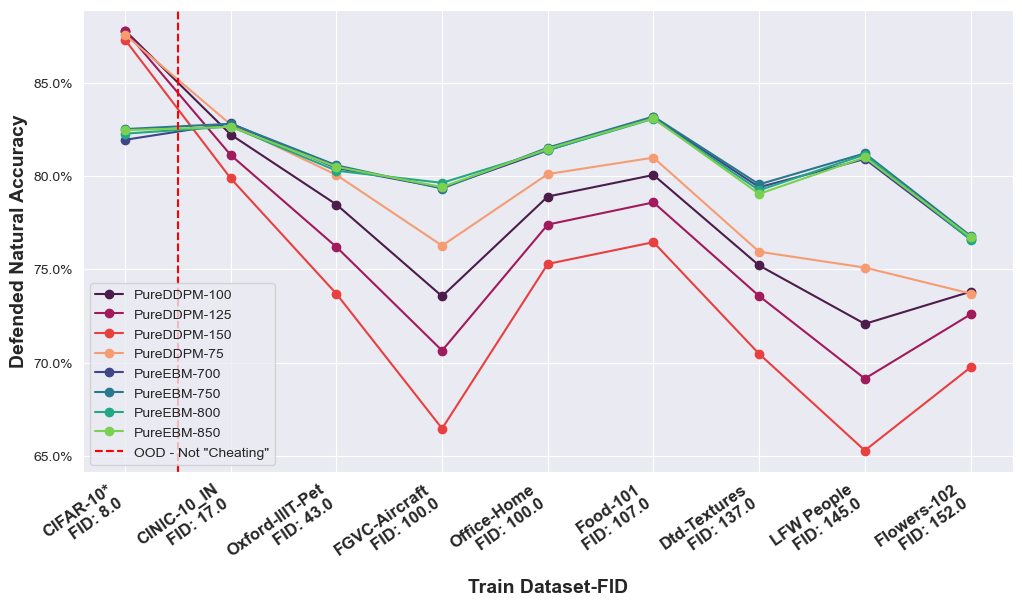

In [2]:
### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/NeuralTangent/POOD.csv')

### Filter Data
df = df[df['Model'] == MODEL]

### Compile Results
df_results = []
for data_key in df['Data Key'].unique():
    df_filt = df[df['Data Key'] == data_key]

    # Extract the defense name
    label = data_key.split('[')[0]

    if label == 'EBM': continue


    # Get Steps
    if label in ['DM_UNET']:
        train_dataset = data_key.split('[')[1].split('_DDPM')[0]
        steps = int(data_key.split('_T[')[1].split(']')[0])
    else:
        steps = int(data_key.split('Steps[')[1].split(']')[0])
        train_dataset = data_key.split('[')[1].split('_nf')[0]
        
    # label += f"-{train_dataset}"



    df_results.append({'Defense': 'PureEBM' if label == 'EBMSNGAN32' else 'PureDDPM',
                        'Steps': steps,
                        'Defense Str': f"PureEBM-{steps}" if label == 'EBMSNGAN32' else f"PureDDPM-{steps}",
                        'Train Dataset': dataset_dict[train_dataset],
                        'FIDs': dataset_fids[train_dataset],
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                    'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)
# df_results

### PLot Results for all Purify Steps
plt.figure(figsize=(12, 6))
pivot_table = df_results.pivot_table(index='Defense Str', columns=['FIDs','Train Dataset'], values='Nat Acc')
pivot_table.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in pivot_table.columns]
defenses = pivot_table.index.get_level_values('Defense Str').unique()

cmap = sns.color_palette('rocket', 4) + sns.color_palette('viridis', 4)
for i, row in enumerate(pivot_table.iterrows()):
    index, values = row
    plt.plot(pivot_table.columns, values, marker='o', color=cmap[i], label=index)

#Make y axis percentage
plt.gca().set_yticklabels(['{:,.1%}'.format(x) for x in plt.gca().get_yticks()])

plt.xticks(rotation=35, ha='right',fontweight='bold',fontsize=12)
plt.xlabel('Train Dataset-FID', fontsize=14, fontweight='bold')
plt.ylabel('Defended Natural Accuracy', fontsize=14, fontweight='bold')
plt.axvline(x=0.5, color='r', linestyle='--',label='OOD - Not "Cheating"')
plt.legend()
plt.savefig('POOD_NTGA_Steps.pdf', bbox_inches='tight')

### Filter Results for best Steps and Save pivot and print latex
df_results = df_results[((df_results['Defense'] == 'PureDDPM') & (df_results['Steps'] == 75)) | ((df_results['Defense'] == 'PureEBM') & (df_results['Steps'] == 750))]

pivot_NTG = df_results.pivot_table(index='Defense', columns=['FIDs','Train Dataset'], values='Nat Acc')
pivot_NTG.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in pivot_NTG.columns]

In [3]:
df_results.pivot_table(index='Defense', columns=['FIDs','Train Dataset'], values='Nat Acc Str',aggfunc=lambda x: ' '.join(x))

FIDs                  8           17              43            100  \
Train Dataset   CIFAR-10* CINIC-10_IN Oxford-IIIT-Pet FGVC-Aircraft   
Defense                                                               
PureDDPM       87.58±0.28  82.76±0.17      80.06±0.43    76.27±0.30   
PureEBM        82.52±0.31  82.80±0.27      80.58±0.24    79.33±0.27   

FIDs                              107          137         145         152  
Train Dataset Office-Home    Food-101 Dtd-Textures  LFW People Flowers-102  
Defense                                                                     
PureDDPM       80.11±0.27  80.99±0.19   75.95±0.36  75.10±0.28  73.71±0.34  
PureEBM        81.52±0.31  83.19±0.36   79.56±0.27  81.22±0.14  76.80±0.37

## Plot All

/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_49280/3568775089.py:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_49280/3568775089.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(pivot_NTG.columns, rotation=35, ha='right',fontweight='bold',fontsize=14)
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_49280/3568775089.py:63: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_49280/3568775089.py:64: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_xticklabels(pivot_NTG.columns, rotation=35, ha='right',fontweight='bold',fontsize=14)


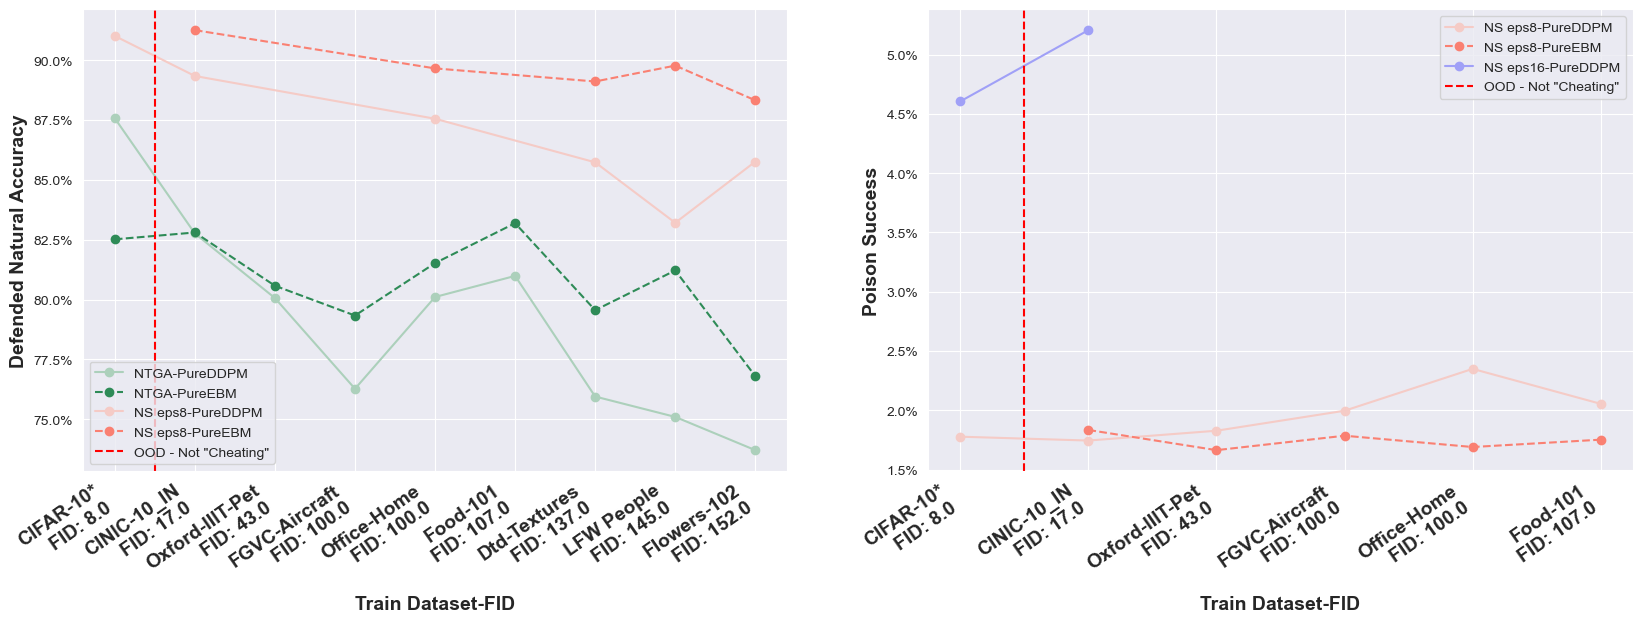

In [118]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

### Plot Natural Accuracies


# NTGA
cmap = sns.color_palette('light:seagreen',4)
for i, row in enumerate(pivot_NTG.iterrows()):
    index, values = row
    if 'DDPM' in index:
        axs[0].plot(pivot_NTG.columns, values, marker='o', label=f'NTGA-{index}', color=cmap[i+1])
    else:
        axs[0].plot(pivot_NTG.columns, values, marker='o', linestyle='--', label=f'NTGA-{index}', color=cmap[i+2])

# Narc 8
cmap = sns.color_palette('light:salmon', 4)
for i, row in enumerate(pivot_Narc_8_NatAcc.iterrows()):
    index, values = row
    if 'DDPM' in index:
        axs[0].plot(pivot_Narc_8_NatAcc.columns, values, marker='o', label=f'NS eps8-{index}', color=cmap[i+1])
    else:
        axs[0].plot(pivot_Narc_8_NatAcc.columns, values, marker='o', linestyle='--', label=f'NS eps8-{index}', color=cmap[i+2])
    # axs[0].plot(pivot_Narc_8_NatAcc.columns, values, marker='o', linestyle='--', label=f'{index}-NS eps8', color=cmap[i+2])

# # Narc 16
# cmap = sns.color_palette('light:b', 4)
# for i, row in enumerate(pivot_Narc_16_NatAcc.iterrows()):
#     index, values = row
#     if 'DDPM' in index:
#         axs[0].plot(pivot_Narc_16_NatAcc.columns, values, marker='o', label=f'NS eps16-{index}', color=cmap[i+1])
#     else:
#         axs[0].plot(pivot_Narc_16_NatAcc.columns, values, marker='o', linestyle='--', label=f'NS eps16-{index}', color=cmap[i+2])
                    



axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])
axs[0].set_xticklabels(pivot_NTG.columns, rotation=35, ha='right',fontweight='bold',fontsize=14)
axs[0].set_xlabel('Train Dataset-FID', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Defended Natural Accuracy', fontsize=14, fontweight='bold')
axs[0].axvline(x=0.5, color='r', linestyle='--',label='OOD - Not "Cheating"')
axs[0].legend()

### Plot Poison Success
# Narc 8 
cmap = sns.color_palette('light:salmon', 4)
for i, row in enumerate(pivot_Narc_8_Poison.iterrows()):
    index, values = row
    if 'DDPM' in index:
        axs[1].plot(pivot_Narc_8_Poison.columns, values, marker='o', label=f'NS eps8-{index}', color=cmap[i+1])
    else:
        axs[1].plot(pivot_Narc_8_Poison.columns, values, marker='o', linestyle='--', label=f'NS eps8-{index}', color=cmap[i+2])

# Narc 16
cmap = sns.color_palette('light:b', 4)
for i, row in enumerate(pivot_Narc_16_Poison.iterrows()):
    index, values = row
    if 'DDPM' in index:
        axs[1].plot(pivot_Narc_16_Poison.columns, values, marker='o', label=f'NS eps16-{index}', color=cmap[i+1])
    else:
        axs[1].plot(pivot_Narc_16_Poison.columns, values, marker='o', linestyle='--', label=f'NS eps16-{index}', color=cmap[i+2])

axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])
axs[1].set_xticklabels(pivot_NTG.columns, rotation=35, ha='right',fontweight='bold',fontsize=14)
axs[1].set_xlabel('Train Dataset-FID', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Poison Success', fontsize=14, fontweight='bold')
axs[1].axvline(x=0.5, color='r', linestyle='--',label='OOD - Not "Cheating"')
axs[1].legend()